# AUROC n_points sweep: finding the sweet spot

The sparse 12-point AUROC undershoots d' values, while dense methods
(sklearn, upper-envelope with 1000 pts) produce non-monotonic d'(ISI=1)
vs sigma1 curves.

This notebook sweeps over many `n_points` values in `compute_auroc_sparse`
to find the number of ROC sampling points that:
1. Eliminates the non-monotonic bump
2. Doesn't undershoot d' relative to sklearn

| n_points | Description |
|----------|-------------|
| 6–12 | Very sparse — may undershoot |
| 16–64 | Moderate — sweet spot candidate |
| 100–500 | Dense — approaches sklearn behavior |

In [1]:
import sys, os, yaml, torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter, defaultdict
from scipy.spatial.distance import pdist
from sklearn.metrics import roc_auc_score, roc_curve

sys.path.append('/orcd/data/jhm/001/om2/jmhicks/projects/TextureStreaming/code/')
sys.path.append('/orcd/data/jhm/001/om2/bjmedina/auditory-memory/memory/utls/')
sys.path.append('/orcd/data/jhm/001/om2/bjmedina/auditory-memory/memory/src/model/')
sys.path.append('/orcd/data/jhm/001/om2/bjmedina/auditory-memory/memory/')

from chexture_choolbox.auditorytexture.texture_model import TextureModel
from chexture_choolbox.auditorytexture.helpers import FlattenStats
from texture_prior.params import model_params, statistics_set, texture_dataset
from texture_prior.utils import path

from utls.plotting import ensure_dir
from utls.loading import (
    load_results_with_exclusion_2,
    move_sequences_to_used,
    load_results_with_exclusion_no_dropping,
)
from utls.runners_v2 import run_experiment_scores, make_noise_schedule
from utls.runners_utils import *
from utls.analysis_helpers import auroc_to_dprime
from encoders import *

from utls.toy_experiments import (
    make_toy_experiment_list,
    make_compact_multi_isi_sequences,
    make_high_diversity_sequences,
    infer_trial_isis,
)
from utls.sigma_fitting import (
    log_mid,
    compute_auroc_sparse,
    _compute_auroc_upper_envelope,
    auc_to_dprime,
)

try:
    get_ipython()
    from tqdm.notebook import tqdm, trange
except NameError:
    from tqdm import tqdm, trange

## 1. Load config & data

In [2]:
def load_config(cfg_path):
    cfg_path = Path(cfg_path)
    if not cfg_path.exists():
        raise FileNotFoundError(cfg_path)
    with open(cfg_path) as f:
        return yaml.safe_load(f), cfg_path


CONFIG_PATH = (
    "/orcd/data/jhm/001/om2/bjmedina/auditory-memory/memory/"
    "model_yamls/three-regime/resnet50/nontime_avg/run_000005.yaml"
)

model_cfg, model_cfg_path = load_config(CONFIG_PATH)
print(model_cfg)

{'results_root': '/orcd/data/jhm/001/om2/bjmedina/auditory-memory/memory', 'tag': 'slurm', 'experiment': {'is_multi': True, 'n_seqs': 36, 'n_samples': 50, 'which_task': 0}, 'metric': 'cosine', 'noise_model': {'name': 'three-regime', 'sigma0_min': 3.0, 'sigma0_max': 0.5, 'sigma1_min': 0.1, 'sigma1_max': 0.6, 'sigma2_min': 0.0005, 'sigma2_max': 0.1, 't_step': 5}, 'run_id': 'run_000005', 'representation': {'type': 'resnet50', 'layer': 'layer4', 'time_avg': False}}


In [3]:
# ---- experiment ----
exp_cfg = model_cfg["experiment"]
which_task = exp_cfg["which_task"]
is_multi = exp_cfg["is_multi"]
which_isi = exp_cfg.get("which_isi", None)

isis = [0, 1, 2, 4, 8, 16, 32, 64] if is_multi else [0, which_isi]

# ---- metric ----
metric = model_cfg["metric"]

# ---- noise model ----
noise_cfg = model_cfg["noise_model"]
noise_mode = noise_cfg["name"]
t_step = noise_cfg["t_step"]

# ---- representation ----
repr_cfg = model_cfg["representation"]
time_avg = repr_cfg["time_avg"]
encoder_type = repr_cfg["type"]
layer = repr_cfg.get("layer", None)
pc_dims = repr_cfg.get("pc_dims", None)

# ---- load human data ----
exp_list, all_files, name_to_idx, human_runs, task_name, hr_task_name = (
    load_experiment_data(which_task, which_isi, is_multi, old=False)
)

human_curve = compute_human_curve(human_runs, is_multi, which_isi)
print("ISIs:", isis)
print("Human d' curve:", human_curve)
print(f"Total real sequences: {len(exp_list)}")

/orcd/data/jhm/001/om2/bjmedina/auditory-memory/memory/utls/runners_utils.py:210: RuntimeWarning: Mean of empty slice
  dprimes.append(np.nanmean(aucs))


ISIs: [0, 1, 2, 4, 8, 16, 32, 64]
Human d' curve: [3.4645268  3.02938408 2.42755231 2.1539997  2.00406542 1.89978555
 1.76090493 1.57359499]
Total real sequences: 104


## 2. Build encoder & encode stimuli

In [4]:
NN_ENCODERS = {"kell2018", "resnet50"}
encoder_task = (
    "word_speaker_audioset" if encoder_type in NN_ENCODERS else "audioset"
)

encoder_cfg = dict(
    encoder_type=encoder_type,
    model_name=encoder_type,
    task=encoder_task,
    statistics_dict=statistics_set.statistics,
    model_params=model_params,
    pc_dims=pc_dims,
    sr=20000,
    duration=2.0,
    rms_level=0.05,
    time_avg=time_avg,
    device="cuda",
)

if encoder_type in NN_ENCODERS:
    encoder_cfg["layer"] = layer
if encoder_type == "texture":
    encoder_cfg["pc_dims"] = pc_dims

encoder_name = make_encoder_name(encoder_cfg)
print("Encoder name:", encoder_name)

encoder = build_encoder(encoder_cfg)
X = encode_stimuli(encoder, all_files)
X_np = X.detach().cpu().numpy()
print("Encoded shape:", X_np.shape, "  any NaN?", torch.isnan(X).any().item())

Encoder name: resnet50-layer4
LOADING FROM /orcd/data/jhm/001/om2/bjmedina/models/cochdnn/model_directories/resnet50_word_speaker_audioset/
=> loading checkpoint '/orcd/data/jhm/001/om2/bjmedina/models/cochdnn/model_checkpoints/audio_rep_training_cochleagram_1/standard_training_word_and_audioset_and_speaker_decay_lr/542752d7-9849-49ff-b84a-6758a81585b4/5_checkpoint.pt'
=> loaded checkpoint '/orcd/data/jhm/001/om2/bjmedina/models/cochdnn/model_checkpoints/audio_rep_training_cochleagram_1/standard_training_word_and_audioset_and_speaker_decay_lr/542752d7-9849-49ff-b84a-6758a81585b4/5_checkpoint.pt' (epoch 6)


/orcd/data/jhm/001/om2/gelbanna/miniconda3/envs/asr312/lib/python3.12/site-packages/chcochleagram/downsampling.py:68: UserWarning: Plan failed with a cudnnException: CUDNN_BACKEND_EXECUTION_PLAN_DESCRIPTOR: cudnnFinalize Descriptor Failed cudnn_status: CUDNN_STATUS_NOT_SUPPORTED (Triggered internally at /opt/conda/conda-bld/pytorch_1712608847532/work/aten/src/ATen/native/cudnn/Conv_v8.cpp:919.)
  x = ch.nn.functional.conv1d(x, self.downsample_filter,


Encoded shape: (80, 186368)   any NaN? False


## 3. Parameter bounds & stimulus pool

In [5]:
d50 = 1

param_bounds = {
    "sigma0": (noise_cfg["sigma0_min"], 22),
    "sigma1": (0.01, 10 * d50),
    "sigma2": (noise_cfg["sigma2_min"] * d50, 0.5 * d50),
}

print("Parameter bounds:")
for k, v in param_bounds.items():
    print(f"  {k}: ({v[0]:.6f}, {v[1]:.6f})")

# Stimulus pool for sequence generation
stimulus_pool = sorted({s for seq in exp_list for s in seq})
print(f"\nStimulus pool size: {len(stimulus_pool)}")

Parameter bounds:
  sigma0: (3.000000, 22.000000)
  sigma1: (0.010000, 10.000000)
  sigma2: (0.000500, 0.500000)

Stimulus pool size: 80


## 4. Human d' targets

In [6]:
isi_to_hc_idx = {isi_val: i for i, isi_val in enumerate(isis)}

sigma1_human = {isi: float(human_curve[isi_to_hc_idx[isi]]) for isi in [1, 2, 4]}

print("Stage B targets (sigma1):")
for isi, dp in sigma1_human.items():
    print(f"  ISI {isi}: human d' = {dp:.4f}")

# Initial value for sigma2 (not being fitted)
sigma2_init = log_mid(*param_bounds["sigma2"])
print(f"\nFixed sigma2 = {sigma2_init:.6f}")

Stage B targets (sigma1):
  ISI 1: human d' = 3.0294
  ISI 2: human d' = 2.4276
  ISI 4: human d' = 2.1540

Fixed sigma2 = 0.015811


---
## 5. AUROC methods — parameterized by n_points

In [7]:
N_POINTS_GRID = [12, 24, 48, 96, 200, 500]


def make_sparse_dprime_fn(n_pts):
    """Factory: return a (hits, fas) -> (dprime, auroc) function for given n_pts."""
    def fn(hits, fas):
        auroc = compute_auroc_sparse(hits, fas, n_points=n_pts)
        if np.isnan(auroc):
            return np.nan, np.nan
        return auc_to_dprime(auroc), auroc
    return fn


def compute_dprime_sklearn(hits, fas):
    """Reference: sklearn roc_auc_score (standard full ROC)."""
    hits, fas = np.asarray(hits), np.asarray(fas)
    if len(hits) == 0 or len(fas) == 0:
        return np.nan, np.nan
    y_true = np.concatenate([np.ones(len(hits)), np.zeros(len(fas))])
    scores = np.concatenate([hits, fas])
    auroc = roc_auc_score(y_true, -scores)
    return float(auroc_to_dprime(auroc)), auroc


# Build METHODS dict: sparse-Npt for each N, plus sklearn reference
METHODS = {f"sparse-{n}pt": make_sparse_dprime_fn(n) for n in N_POINTS_GRID}
METHODS["sklearn"] = compute_dprime_sklearn

print(f"Methods defined: {len(METHODS)} total")
print(f"  n_points grid: {N_POINTS_GRID}")
print(f"  + sklearn reference")

Methods defined: 7 total
  n_points grid: [12, 24, 48, 96, 200, 500]
  + sklearn reference


---
## 6. Sweep function (collects raw scores)

In [8]:
def sweep_sigma1_detailed(
    sigma1_value, sigma0, sigma2, t_step,
    noise_mode, metric, X0, name_to_idx,
    experiment_list, target_isis,
    human_dprimes_by_isi=None,
    n_mc=64, seed=0,
):
    """
    Evaluate a single sigma1 value and return raw hit/FA scores
    for post-hoc AUROC method comparison.
    """
    seq_trial_isis = [infer_trial_isis(seq) for seq in experiment_list]

    all_hits_by_isi = {isi: [] for isi in target_isis}
    all_fas = []

    for rep in range(n_mc):
        for si, seq in enumerate(experiment_list):
            t_isis = seq_trial_isis[si]
            run_out = run_experiment_scores(
                sigma0=sigma0,
                sigma1=sigma1_value,
                sigma2=sigma2,
                t_step=t_step,
                rate=0,
                noise_mode=noise_mode,
                metric=metric,
                X0=X0,
                name_to_idx=name_to_idx,
                experiment_list=[seq],
                debug=False,
                seed=seed + rep * 1000 + si,
            )
            h = np.asarray(run_out["hits"])
            f = np.asarray(run_out["fas"])
            if len(h) != len(t_isis):
                continue
            for isi_val in target_isis:
                mask = np.array(t_isis) == isi_val
                all_hits_by_isi[isi_val].extend(h[mask].tolist())
            all_fas.extend(f.tolist())

    fas_arr = np.array(all_fas)

    return {
        "sigma1": sigma1_value,
        "hit_scores_by_isi": {isi: np.array(v) for isi, v in all_hits_by_isi.items()},
        "fa_scores": fas_arr,
        "n_hits_by_isi": {isi: len(v) for isi, v in all_hits_by_isi.items()},
        "n_fas": len(fas_arr),
    }


def run_sigma1_sweep(
    sigma0, sigma1_grid, sigma2, t_step,
    experiment_list, target_isis,
    human_dprimes_by_isi,
    noise_mode, metric, X0, name_to_idx,
    n_mc=64, seed=0, desc="sigma1 sweep",
):
    """Run sweep_sigma1_detailed for each sigma1 in the grid."""
    results = []
    for i in trange(len(sigma1_grid), desc=desc):
        r = sweep_sigma1_detailed(
            sigma1_value=sigma1_grid[i],
            sigma0=sigma0,
            sigma2=sigma2,
            t_step=t_step,
            noise_mode=noise_mode,
            metric=metric,
            X0=X0,
            name_to_idx=name_to_idx,
            experiment_list=experiment_list,
            target_isis=target_isis,
            human_dprimes_by_isi=human_dprimes_by_isi,
            n_mc=n_mc,
            seed=seed + i * 100_000,
        )
        results.append(r)
    return results

In [9]:
def recompute_dprime_all_methods(sweep_results, target_isi=1):
    """Recompute d' from raw scores using all AUROC methods."""
    out = {name: {"dprime": [], "auroc": []} for name in METHODS}
    sigma1_vals = []
    for r in sweep_results:
        sigma1_vals.append(r["sigma1"])
        hits = r["hit_scores_by_isi"][target_isi]
        fas = r["fa_scores"]
        for name, fn in METHODS.items():
            dp, auc = fn(hits, fas)
            out[name]["dprime"].append(dp)
            out[name]["auroc"].append(auc)
    return np.array(sigma1_vals), out


print("Recompute function ready.")

Recompute function ready.


---
## 7. Generate ISI=[1]-only sequences & run sweeps

In [19]:
# Generate ISI=[1]-only compact sequences
ISI1_EXPS, ISI1_ISI_KEYS = make_high_diversity_sequences(
    stimulus_pool=stimulus_pool,
    isi_values=[1],
    n_sequences=8,
    length=60,
    min_pairs_per_isi=5,
    seed=1000,
)
print(f"Generated {len(ISI1_EXPS)} ISI=[1] sequences, {len(ISI1_EXPS[0])} trials each")

for seq in ISI1_EXPS:
    counts = Counter(infer_trial_isis(seq))
    print(f"  ISI=1 pairs: {counts.get(1, 0)}")

Aggregate ISI usage across all sequences:
  ISI -1: 160
  ISI 1: 320
Generated 8 ISI=[1] sequences, 60 trials each
  ISI=1 pairs: 20
  ISI=1 pairs: 20
  ISI=1 pairs: 20
  ISI=1 pairs: 20
  ISI=1 pairs: 20
  ISI=1 pairs: 20
  ISI=1 pairs: 20
  ISI=1 pairs: 20


In [20]:
# --- sigma1 grid ---
n_grid = 5
SIGMA1_GRID = np.exp(np.linspace(np.log(0.9), np.log(15.0), n_grid))
N_MC = 12

print(f"Sigma1 grid: {len(SIGMA1_GRID)} points, range [{SIGMA1_GRID[0]:.4f}, {SIGMA1_GRID[-1]:.4f}]")

# --- Sweep for each sigma0 ---
SIGMA0_VALUES = [5, 10, 20]

sweep_by_sigma0 = {}
for s0 in SIGMA0_VALUES:
    print(f"\n--- sigma0 = {s0} ---")
    sweep_by_sigma0[s0] = run_sigma1_sweep(
        sigma0=s0, sigma1_grid=SIGMA1_GRID, sigma2=sigma2_init,
        t_step=t_step, experiment_list=ISI1_EXPS,
        target_isis=[1], human_dprimes_by_isi=sigma1_human,
        noise_mode=noise_mode, metric=metric,
        X0=X, name_to_idx=name_to_idx,
        n_mc=N_MC, seed=int(200_000 * s0),
        desc=f"sigma0={s0}",
    )

print("\nAll sweeps done.")

Sigma1 grid: 5 points, range [0.9000, 15.0000]

--- sigma0 = 5 ---


sigma0=5:   0%|          | 0/5 [00:00<?, ?it/s]


--- sigma0 = 10 ---


sigma0=10:   0%|          | 0/5 [00:00<?, ?it/s]


--- sigma0 = 20 ---


sigma0=20:   0%|          | 0/5 [00:00<?, ?it/s]


All sweeps done.


---
## 8. d' vs sigma1 — colored by n_points

/tmp/ipykernel_29808/1134811146.py:47: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


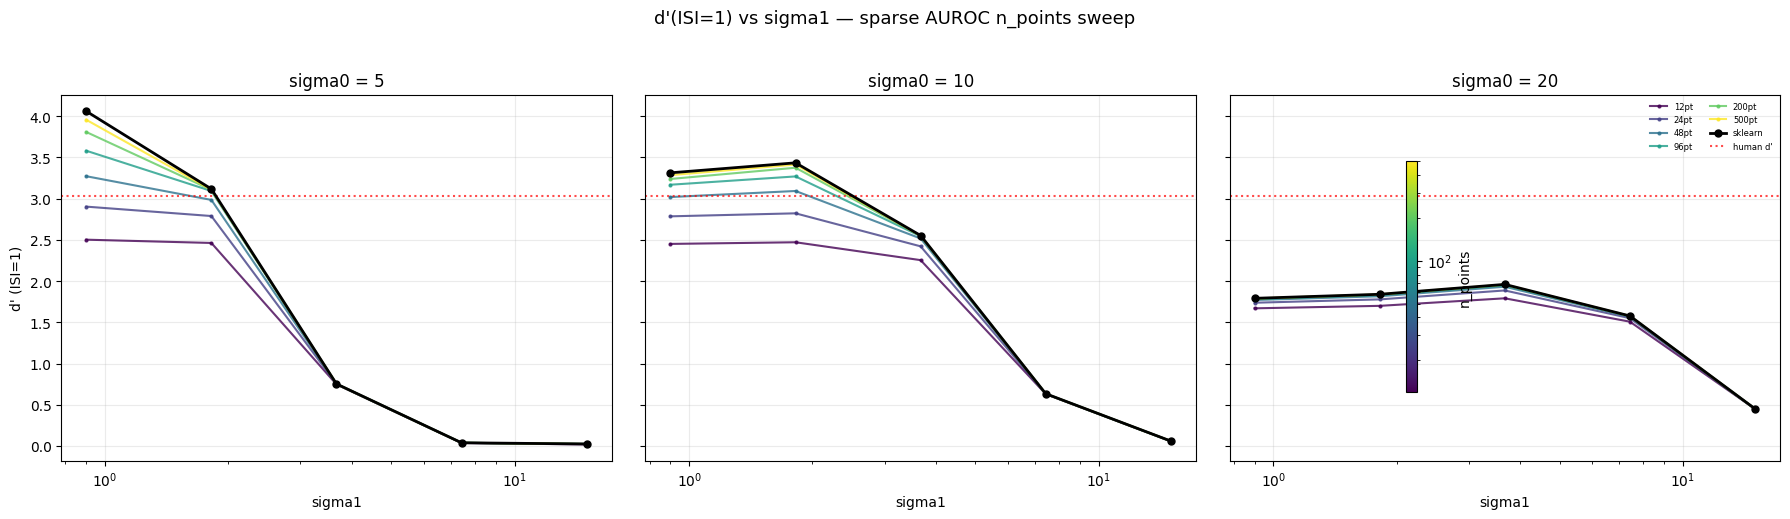

In [21]:
from matplotlib.colors import LogNorm
import matplotlib.cm as cm

cmap = cm.viridis
norm = LogNorm(vmin=min(N_POINTS_GRID), vmax=max(N_POINTS_GRID))

fig, axes = plt.subplots(1, len(SIGMA0_VALUES),
                         figsize=(6 * len(SIGMA0_VALUES), 5), sharey=True)
if len(SIGMA0_VALUES) == 1:
    axes = [axes]

for ax, s0 in zip(axes, SIGMA0_VALUES):
    s1_vals, method_data = recompute_dprime_all_methods(sweep_by_sigma0[s0], target_isi=1)

    # Plot each sparse-Npt curve
    for n in N_POINTS_GRID:
        key = f"sparse-{n}pt"
        color = cmap(norm(n))
        ax.plot(s1_vals, method_data[key]["dprime"],
                ls="-", marker=".", ms=4, color=color,
                alpha=0.8, label=f"{n}pt")

    # sklearn reference (bold black)
    ax.plot(s1_vals, method_data["sklearn"]["dprime"],
            ls="-", marker="o", ms=5, color="black", lw=2,
            label="sklearn", zorder=10)

    # Human d' reference
    ax.axhline(sigma1_human[1], ls=":", color="red", alpha=0.7, label="human d'")

    ax.set_xscale("log")
    ax.set_xlabel("sigma1")
    ax.set_title(f"sigma0 = {s0}")
    ax.grid(alpha=0.25)

# Legend on leftmost panel only
axes[0].set_ylabel("d' (ISI=1)")
axes[-1].legend(fontsize=6, frameon=False, ncol=2, loc="upper right")

# Colorbar
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes, shrink=0.6, pad=0.02)
cbar.set_label("n_points")

fig.suptitle("d'(ISI=1) vs sigma1 — sparse AUROC n_points sweep", y=1.03, fontsize=13)
fig.tight_layout()
plt.show()

---
## 9. Monotonicity analysis

For each `n_points`, count non-monotonic steps (where d' *increases*
as sigma1 increases). A perfectly monotonically decreasing curve has 0
non-monotonic steps.

In [ ]:
def monotonicity_violations(dprime_vals):
    """Count consecutive pairs where d' increases (should decrease with sigma1)."""
    dp = np.array(dprime_vals)
    diffs = np.diff(dp)
    return int(np.sum(diffs > 0))


def max_violation_magnitude(dprime_vals):
    """Largest upward jump in d' (should be 0 for monotonic)."""
    dp = np.array(dprime_vals)
    diffs = np.diff(dp)
    pos = diffs[diffs > 0]
    return float(pos.max()) if len(pos) > 0 else 0.0


def mean_abs_error_vs_sklearn(dprime_sparse, dprime_sklearn):
    """Mean absolute error of sparse d' vs sklearn d'."""
    return float(np.mean(np.abs(np.array(dprime_sparse) - np.array(dprime_sklearn))))


# Build summary table
print(f"{'n_pts':>6} | ", end="")
for s0 in SIGMA0_VALUES:
    print(f"  sigma0={s0:>2}  viol | max_viol |  MAE  |", end="")
print()
print("-" * (8 + 42 * len(SIGMA0_VALUES)))

summary_data = {}  # n -> {s0: {violations, max_viol, mae}}

all_methods_list = ["sklearn"] + [f"sparse-{n}pt" for n in N_POINTS_GRID]

for label in all_methods_list:
    n_str = label.replace("sparse-", "").replace("pt", "") if "sparse" in label else label
    print(f"{n_str:>6} | ", end="")
    for s0 in SIGMA0_VALUES:
        s1_vals, method_data = recompute_dprime_all_methods(sweep_by_sigma0[s0], target_isi=1)
        dp = method_data[label]["dprime"]
        dp_sk = method_data["sklearn"]["dprime"]
        v = monotonicity_violations(dp)
        mv = max_violation_magnitude(dp)
        mae = mean_abs_error_vs_sklearn(dp, dp_sk)
        print(f"      {v:>1}       {mv:>5.3f}   {mae:>5.3f} |", end="")
    print()

In [ ]:
# Bar chart: total monotonicity violations across all sigma0 values
total_violations = {}
total_mae = {}

for n in N_POINTS_GRID:
    key = f"sparse-{n}pt"
    viol_sum = 0
    mae_sum = 0
    for s0 in SIGMA0_VALUES:
        s1_vals, method_data = recompute_dprime_all_methods(sweep_by_sigma0[s0], target_isi=1)
        viol_sum += monotonicity_violations(method_data[key]["dprime"])
        mae_sum += mean_abs_error_vs_sklearn(
            method_data[key]["dprime"], method_data["sklearn"]["dprime"])
    total_violations[n] = viol_sum
    total_mae[n] = mae_sum / len(SIGMA0_VALUES)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Left: violations
ax1.bar([str(n) for n in N_POINTS_GRID],
        [total_violations[n] for n in N_POINTS_GRID],
        color=[cmap(norm(n)) for n in N_POINTS_GRID], edgecolor="k", lw=0.5)
ax1.set_xlabel("n_points")
ax1.set_ylabel("Total monotonicity violations\n(across all sigma0)")
ax1.set_title("Fewer = better")
ax1.tick_params(axis="x", rotation=45)

# Right: MAE vs sklearn
ax2.bar([str(n) for n in N_POINTS_GRID],
        [total_mae[n] for n in N_POINTS_GRID],
        color=[cmap(norm(n)) for n in N_POINTS_GRID], edgecolor="k", lw=0.5)
ax2.set_xlabel("n_points")
ax2.set_ylabel("Mean |d'(sparse) - d'(sklearn)|")
ax2.set_title("Lower = closer to sklearn")
ax2.tick_params(axis="x", rotation=45)

fig.suptitle("n_points trade-off: monotonicity vs accuracy", fontsize=13, y=1.02)
fig.tight_layout()
plt.show()

# Identify best candidates
print("\n--- Best candidates (0 violations, lowest MAE) ---")
zero_viol = [n for n in N_POINTS_GRID if total_violations[n] == 0]
if zero_viol:
    best = min(zero_viol, key=lambda n: total_mae[n])
    print(f"Zero-violation options: {zero_viol}")
    print(f"Best (lowest MAE): n_points={best}, MAE={total_mae[best]:.4f}")
else:
    print("No n_points value achieved 0 violations.")
    best = min(N_POINTS_GRID, key=lambda n: (total_violations[n], total_mae[n]))
    print(f"Best compromise: n_points={best}, violations={total_violations[best]}, MAE={total_mae[best]:.4f}")